In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit, cross_validate
from src.ElectricSequentialRegressor import ElectricSequentialRegressor
from scipy.stats import randint, uniform
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, r2_score, make_scorer
import joblib
from src.Utils import mse_column_score, plot_performance_analysis, shifted_mape

<h2>Lectura y Tratamiento de Datos</h2>

In [2]:
X = pd.read_csv('../dataset/dataset_in.txt', index_col=0).drop(columns=['P2', 'Q2'])
y_columns = [f'V{i}' for i in range(2,15)] + ['PERD', 'QGEN7'] #V1 ES SIEMPRE 1.0 EN DATASET
Y = pd.read_csv('../dataset/dataset_out.txt', index_col=0).loc[:, y_columns]
#FILTRAR DATOS ERRÓNEOS (PÉRDIDAS NEGATIVAS)
mask = Y['PERD'] >= 0
X = X[mask]
Y = Y[mask]

**Validación por Retención (Tratamiento como Serie Temporal)**

In [3]:
# VALIDACIÓN POR RETENCIÓN PARA EVALUACIÓN FINAL DEL MEJOR MODELO
n_samples = X.shape[0]
train_size = int(n_samples * 0.8)
x_train, y_train = X[:train_size], Y[:train_size]
x_test, y_test = X[train_size:], Y[train_size:]

<h2>Búsqueda Aleatoria de Hiperparámetros</h2>

In [4]:
random_model = ElectricSequentialRegressor(RandomForestRegressor(n_jobs=1, random_state=42), RandomForestRegressor(n_jobs=1, random_state=42))
random_grid = {
    'estimator1__n_estimators': randint(30, 101),
    'estimator1__max_depth': randint(10, 51),
    'estimator1__min_samples_split': randint(2, 21),
    'estimator1__max_features': uniform(0.1, 0.9),
    'estimator2__n_estimators': randint(80, 251),
    'estimator2__max_depth': randint(10, 51),
    'estimator2__min_samples_split': randint(2, 21),
    'estimator2__max_features': uniform(0.1, 0.9)
}
random_scoring = {
    'mse_global': 'neg_mean_squared_error',
    'mse_v_perd': make_scorer(mse_column_score, col_idx=[c for c in range(0, Y.shape[1] - 1)], greater_is_better=False),
    'mse_qgen7': make_scorer(mse_column_score, col_idx=-1, greater_is_better=False),
}
random_search = RandomizedSearchCV(random_model, random_grid, n_iter=30,
                                   cv=TimeSeriesSplit(n_splits=3), scoring=random_scoring, refit='mse_global',
                                   n_jobs=-1, verbose=2, random_state=42, return_train_score=True)

In [5]:
random_search.fit(x_train, y_train)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


,estimator,ElectricSeque...dom_state=42))
,param_distributions,"{'estimator1__max_depth': <scipy.stats....00181E7A07610>, 'estimator1__max_features': <scipy.stats....00181E7A0C250>, 'estimator1__min_samples_split': <scipy.stats....00181E7A07C10>, 'estimator1__n_estimators': <scipy.stats....00181E6643190>, ...}"
,n_iter,30
,scoring,"{'mse_global': 'neg_mean_squared_error', 'mse_qgen7': make_scorer(m...', col_idx=-1), 'mse_v_perd': make_scorer(m..., 11, 12, 13])}"
,n_jobs,-1
,refit,'mse_global'
,cv,TimeSeriesSpl...est_size=None)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


<h2>Evaluación del Mejor Modelo Aleatorio</h2>

In [6]:
# PREDICCIONES DEL MEJOR MODELO CON VALORES DEL "FUTURO" X_TEST, YA QUE LO TRATAMOS COMO SERIE TEMPORAL
best_random_model = random_search.best_estimator_
random_predictions = best_random_model.predict(x_test)
print('MSE: ' + str(random_search.best_score_))
random_results = pd.DataFrame(random_search.cv_results_)
random_results.loc[:, ['mean_test_mse_global', 'mean_test_mse_v_perd', 'mean_test_mse_qgen7']]

MSE: -0.036428580041893026


,mean_test_mse_global,mean_test_mse_v_perd,mean_test_mse_qgen7
0,-0.043873,-0.046984,-0.000324
1,-0.056056,-0.060036,-0.000325
2,-0.055657,-0.059607,-0.000349
3,-0.045658,-0.048896,-0.000325
4,-0.038288,-0.040990,-0.000466
5,-0.038260,-0.040970,-0.000319
6,-0.050456,-0.054037,-0.000331
7,-0.039671,-0.042481,-0.000327
8,-0.040035,-0.042862,-0.000453
9,-0.038693,-0.041434,-0.000324


In [7]:
random_MAE = mean_absolute_error(y_test, random_predictions, multioutput='raw_values')
random_MAPE = mean_absolute_percentage_error(y_test, random_predictions, multioutput='raw_values')
#DESPLAZAMIENTO PARA EVITAR DIVISIÓN POR VALORES CERCANO A 0. CONSECUENCIA: MAPE ALGO OPTIMISTA
random_MAPE_shifted = mean_absolute_percentage_error(y_test + 1.0, random_predictions + 1.0, multioutput='raw_values')
random_R2 = r2_score(y_test, random_predictions, multioutput='raw_values')

In [8]:
# RESULTADOS CON MAPE DESPLAZADO
random_data_score_shifted = np.vstack([random_MAE, random_MAPE_shifted, random_R2])
evaluations_shifted = pd.DataFrame(random_data_score_shifted, columns=y_columns, index=['MAE', 'MAPE', 'R2'])
evaluations_shifted

,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,PERD,QGEN7
MAE,0.003143,0.003150,0.003152,0.003152,0.003153,0.003154,0.003151,0.003151,0.003152,0.003152,0.003152,0.004337,0.004337,0.494865,0.006523
MAPE,0.001593,0.001596,0.001598,0.001598,0.001598,0.001599,0.001597,0.001598,0.001598,0.001598,0.001598,0.002192,0.002192,0.055876,0.006137
R2,0.917842,0.918997,0.919607,0.919669,0.919695,0.919747,0.919747,0.919719,0.919749,0.919792,0.919804,0.793553,0.793570,0.948343,0.882999


In [9]:
# RESULTADOS SIN DESPLAZAMIENTO
random_data_score = np.vstack([random_MAE, random_MAPE, random_R2])
evaluations = pd.DataFrame(random_data_score, columns=y_columns, index=['MAE', 'MAPE', 'R2'])
evaluations

,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,PERD,QGEN7
MAE,0.003143,0.003150,0.003152,0.003152,0.003153,0.003154,0.003151,0.003151,0.003152,0.003152,0.003152,0.004337,0.004337,0.494865,6.523493e-03
MAPE,0.003229,0.003238,0.003241,0.003242,0.003243,0.003245,0.003240,0.003241,0.003241,0.003241,0.003241,0.004431,0.004431,0.065098,9.293434e+12
R2,0.917842,0.918997,0.919607,0.919669,0.919695,0.919747,0.919747,0.919719,0.919749,0.919792,0.919804,0.793553,0.793570,0.948343,8.829990e-01


In [10]:
# EVALUACIÓN FINAL CON MEDIA DE VOLTAJES (MAPE DESPLAZADO)
volts_columns = [c for c in y_train.columns if c.startswith('V')]
pd.DataFrame({
    'Voltajes (Desplazados)': evaluations_shifted[volts_columns].mean(axis=1),
    'Pérdidas (Desplazada)': evaluations_shifted['PERD'],
    'Potencia Reactiva (Desplazada)': evaluations_shifted['QGEN7']
})

,Voltajes (Desplazados),Pérdidas (Desplazada),Potencia Reactiva (Desplazada)
MAE,0.003333,0.494865,0.006523
MAPE,0.001689,0.055876,0.006137
R2,0.900115,0.948343,0.882999


In [11]:
# EVALUACIÓN FINAL CON MEDIA DE VOLTAJES (MAPE SIN DESPLAZAMIENTO)
pd.DataFrame({
    'Voltajes': evaluations[volts_columns].mean(axis=1),
    'Pérdidas': evaluations['PERD'],
    'Potencia Reactiva': evaluations['QGEN7']
})

,Voltajes,Pérdidas,Potencia Reactiva
MAE,0.003333,0.494865,6.523493e-03
MAPE,0.003423,0.065098,9.293434e+12
R2,0.900115,0.948343,8.829990e-01


**Validación Cruzada para Contrastación de Resultados**

In [12]:
random_search.best_params_

{'estimator1__max_depth': 20,
 'estimator1__max_features': np.float64(0.9420714947988528),
 'estimator1__min_samples_split': 5,
 'estimator1__n_estimators': 67,
 'estimator2__max_depth': 49,
 'estimator2__max_features': np.float64(0.6457861536936309),
 'estimator2__min_samples_split': 4,
 'estimator2__n_estimators': 191}

In [13]:
evaluate_model_shifted = ElectricSequentialRegressor(RandomForestRegressor(max_features=0.94, max_depth=20, min_samples_split=5, n_estimators=67, n_jobs=1, random_state=42),
                                             RandomForestRegressor(max_depth=49, max_features=0.64, min_samples_split=4, n_estimators=191, n_jobs=1, random_state=42))
evaluate_scoring_shifted = { # EVALUACIÓN CON DESPLAZAMIENTO EN MAPE
    'mse': 'neg_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'mape': make_scorer(shifted_mape, greater_is_better=False),
    'r2': 'r2'
}
evaluate_results_shifted = cross_validate(evaluate_model_shifted, X, Y, scoring=evaluate_scoring_shifted, cv=TimeSeriesSplit(n_splits=5), n_jobs=-1)
print('MSE: ' + str(-evaluate_results_shifted['test_mse'].mean()))
print('MAE: ' + str(-evaluate_results_shifted['test_mae'].mean()))
print('MAPE: ' + str(-evaluate_results_shifted['test_mape'].mean()))
print('R2: ' + str(evaluate_results_shifted['test_r2'].mean()))

MSE: 0.03745654076375964
MAE: 0.03841269504538234
MAPE: 0.005893682826160746
R2: 0.8970979125590294


In [14]:
evaluate_model = ElectricSequentialRegressor(RandomForestRegressor(max_features=0.94, max_depth=20, min_samples_split=5, n_estimators=67, n_jobs=1, random_state=42),
                                             RandomForestRegressor(max_depth=49, max_features=0.64, min_samples_split=4, n_estimators=191, n_jobs=1, random_state=42))
evaluate_scoring = { # EVALUACIÓN SIN DESPLAZAMIENTO EN MAPE
    'mse': 'neg_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'mape': 'neg_mean_absolute_percentage_error',
    'r2': 'r2'
}
evaluate_results = cross_validate(evaluate_model, X, Y, scoring=evaluate_scoring, cv=TimeSeriesSplit(n_splits=5), n_jobs=-1)
print('MSE: ' + str(-evaluate_results['test_mse'].mean()))
print('MAE: ' + str(-evaluate_results['test_mae'].mean()))
print('MAPE: ' + str(-evaluate_results['test_mape'].mean()))
print('R2: ' + str(evaluate_results['test_r2'].mean()))

MSE: 0.03745654076375964
MAE: 0.03841269504538234
MAPE: 604608630215.7952
R2: 0.8970979125590294


<h2>Figuras de Rendimiento del Mejor Modelo</h2>

In [15]:
joblib.dump(best_random_model, '../models/ESR_MO_RandomForest.pkl')

['../models/ESR_MO_RandomForest.pkl']

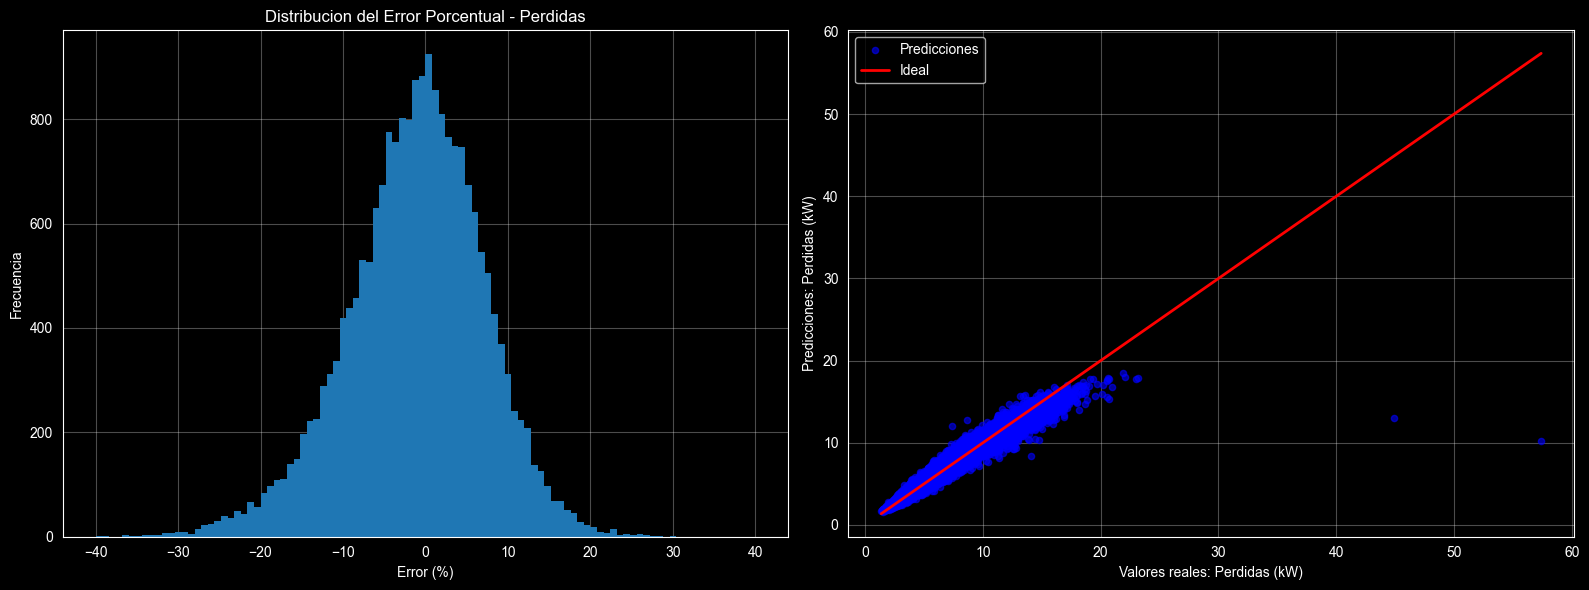

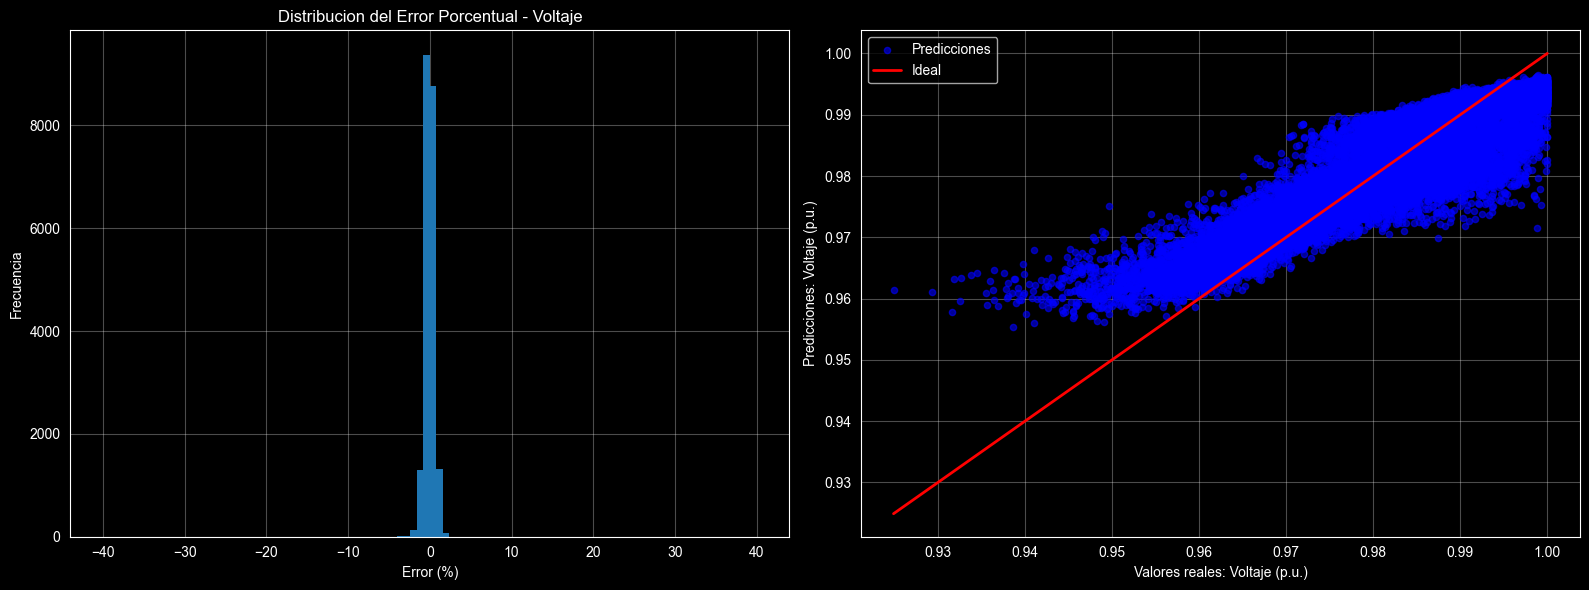

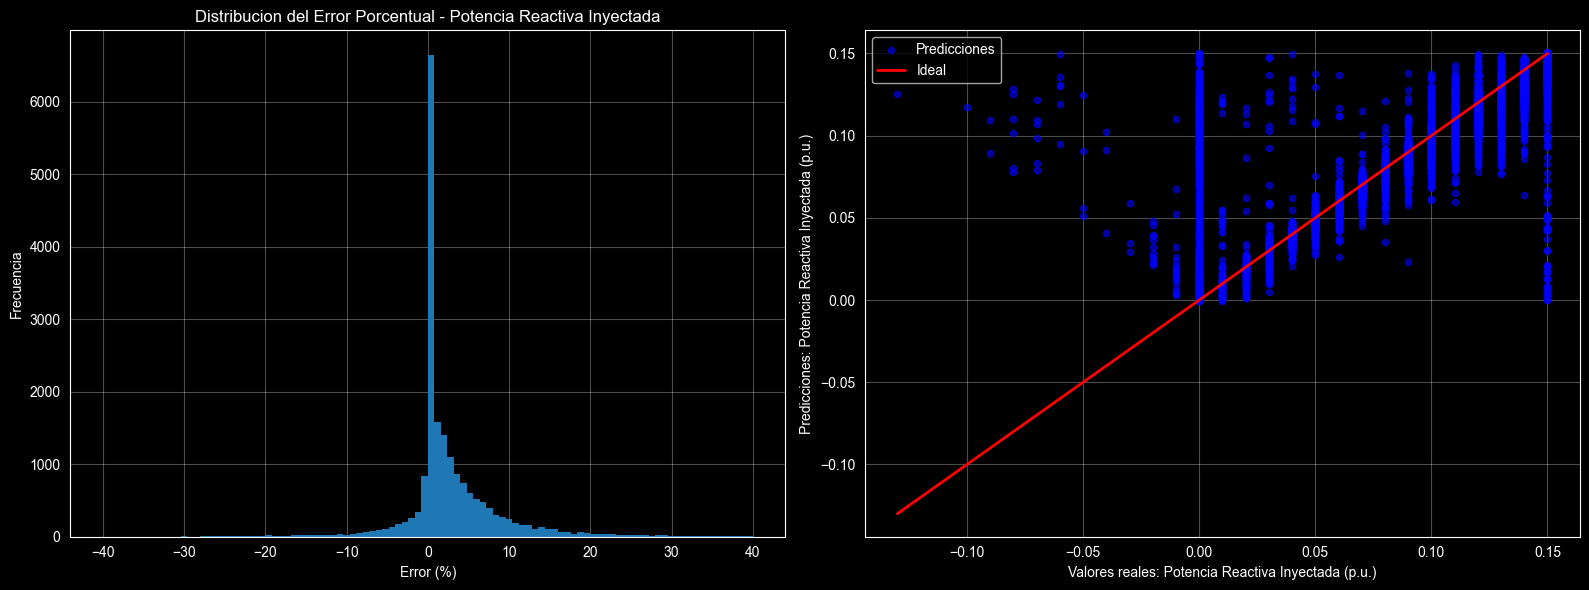

In [16]:
plot_performance_analysis(
    y_test['PERD'],
    random_predictions[:, -2],
    variable_name="Perdidas",
    unit_label="kW",
    path='../figures/RandomForest/ESR_MO_RandomForest_Perd.png'
)
plot_performance_analysis(
    y_test['V13'],
    random_predictions[:, -4],
    variable_name="Voltaje",
    unit_label="p.u.",
    path='../figures/RandomForest/ESR_MO_RandomForest_V13.png'
)
plot_performance_analysis(
    y_test['QGEN7'],
    random_predictions[:, -1],
    variable_name="Potencia Reactiva Inyectada",
    unit_label="p.u.",
    path='../figures/RandomForest/ESR_MO_RandomForest_QGen.png'
)